<a href="https://colab.research.google.com/github/CodeSage54/Deep-Learning/blob/main/CNN_ImageRecognition/CNN_ImageRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem Statement:**

The task at hand involves classifying images of cats and dogs using a
Convolutional Neural Network (CNN). We have a dataset containing images of
cats and dogs and the objective is to train a CNN model to accurately predict the
class of each image.


**Objectives:**

**Data Preparation:**

● Download and extract the cats vs. dogs dataset.

● Organize the dataset into a structured directory format suitable for
TensorFlow’s ImageDataGenerator.

● Split the dataset into training and testing sets.

**Data Augmentation and Preprocessing:**

● Implement data augmentation techniques to increase the diversity of the
training dataset, aiding in the model's ability to generalize.

● Normalize the pixel values of the images for optimal model performance.

**Model Building:**

● Construct a Convolutional Neural Network using TensorFlow and Keras.

● Themodel should contain multiple convolutional layers, pooling layers, and
fully connected layers.

**Training:**

● Compile the model and train it on the prepared dataset.

● Utilize categorical cross entropy as the loss function and stochastic
gradient descent as the optimizer.

● Train the model for a sufficient number of epochs to achieve good
performance


**Evaluation:**

● Evaluate the model's performance on the validation set during training to
monitor for overfitting.

● After training, assess the model's accuracy and make predictions on the
test set.

Prediction:

● Implement a system to make predictions on new images, categorizing
them as either cat or dog.

● Thesystem should be able to take an image (or a batch of images),
preprocess it, and pass it through the model for prediction.

# Download images from TFDS into local directory structure

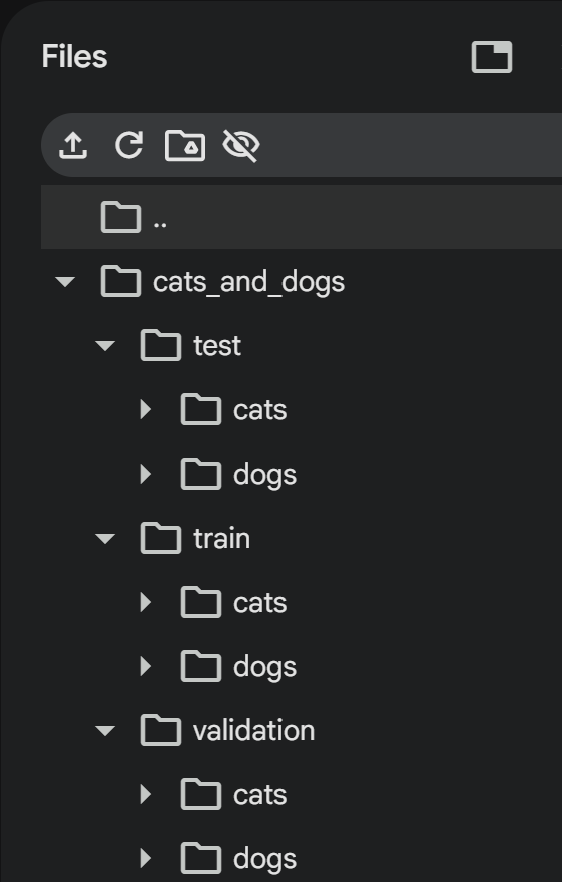

In [14]:
import tensorflow_datasets as tfds
import tensorflow as tf
import os
import shutil

In [2]:
# Download images from tensorflow datasets and arrange them in the above directory structure


# Step 1: Load dataset from TFDS
dataset, info = tfds.load('cats_vs_dogs', with_info=True, as_supervised=True)
train_ds = dataset['train']

# Step 2: Create directories
base_dir = "cats_and_dogs"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "validation")
test_dir = os.path.join(base_dir, "test")

for d in [train_dir, val_dir, test_dir]:
    os.makedirs(os.path.join(d, "cats"), exist_ok=True)
    os.makedirs(os.path.join(d, "dogs"), exist_ok=True)

# Step 3: Split dataset (80% train, 10% val, 10% test)
train_size = int(0.8 * info.splits['train'].num_examples)
val_size   = int(0.1 * info.splits['train'].num_examples)

train_data = train_ds.take(train_size)
val_data   = train_ds.skip(train_size).take(val_size)
test_data  = train_ds.skip(train_size + val_size)

# Step 4: Save images into directories
def save_images(dataset, directory):
    for i, (image, label) in enumerate(tfds.as_numpy(dataset)):
        label_name = "cats" if label == 0 else "dogs"
        file_path = os.path.join(directory, label_name, f"{i}.jpg")
        tf.keras.utils.save_img(file_path, image)

save_images(train_data, train_dir)
save_images(val_data, val_dir)
save_images(test_data, test_dir)

print("Dataset prepared with train, validation, and test directories.")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.2MWWO0_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Dataset prepared with train, validation, and test directories.


# Preprocessing and Augmentation using TF ImageDataGenerator

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation and test data generators (only rescaling)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/cats_and_dogs/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    '/content/cats_and_dogs/validation',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    '/content/cats_and_dogs/test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

Found 18609 images belonging to 2 classes.
Found 2326 images belonging to 2 classes.
Found 2327 images belonging to 2 classes.


# Model Building

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# 2 conv layers, 1 Dense layer and 1 output layer
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150,3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),

    Dropout(0.5),
    Dense(2, activation='softmax')
])

# Use categorical_crossentropy for classification
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=15,
    validation_data=val_generator,
    validation_steps=len(val_generator),
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
582/582 ━━━━━━━━━━━━━━━━━━━━ 141s 228ms/step - accuracy: 0.5860 - loss: 1.1083 - val_accuracy: 0.6926 - val_loss: 0.5761
Epoch 2/15
582/582 ━━━━━━━━━━━━━━━━━━━━ 129s 216ms/step - accuracy: 0.6768 - loss: 0.5989 - val_accuracy: 0.7429 - val_loss: 0.5322
Epoch 3/15
582/582 ━━━━━━━━━━━━━━━━━━━━ 126s 216ms/step - accuracy: 0.7105 - loss: 0.5646 - val_accuracy: 0.6625 - val_loss: 0.8154
Epoch 4/15
582/582 ━━━━━━━━━━━━━━━━━━━━ 140s 212ms/step - accuracy: 0.7163 - loss: 0.5560 - val_accuracy: 0.7408 - val_loss: 0.5377
Epoch 5/15
582/582 ━━━━━━━━━━━━━━━━━━━━ 123s 211ms/step - accuracy: 0.7433 - loss: 0.5198 - val_accuracy: 0.7644 - val_loss: 0.4752
Epoch 6/15
582/582 ━━━━━━━━━━━━━━━━━━━━ 124s 213ms/step - accuracy: 0.7503 - loss: 0.5030 - val_accuracy: 0.7769 - val_loss: 0.4807
Epoch 7/15
582/582 ━━━━━━━━━━━━━━━━━━━━ 123s 212ms/step - accuracy: 0.7699 - loss: 0.4818 - val_accuracy: 0.8194 - val_loss: 0.4199
Epoch 8/15
582/582 ━━━━━━━━━━━━━━━━━━━━ 125s 214ms/step - accuracy: 0.7732 -

# Model Performance Metrics

In [9]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt


# Step 1: Get predictions on test set
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

# Step 2: Get test accuracy
loss, acc = model.evaluate(test_generator)
print(f"Test Accuracy: {acc*100:.2f}%")


# Step 3: Get true labels
y_true = test_generator.classes

# Step 3: Class labels (from generator)
class_labels = list(test_generator.class_indices.keys())



# Step 5: Classification report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Step 6: Confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:")
print(cm)

73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.8068 - loss: 0.4298
Test Accuracy: 80.32%
Classification Report:

              precision    recall  f1-score   support

        cats       0.49      0.38      0.43      1143
        dogs       0.51      0.61      0.55      1184

    accuracy                           0.50      2327
   macro avg       0.50      0.50      0.49      2327
weighted avg       0.50      0.50      0.49      2327


Confusion Matrix:
[[439 704]
 [462 722]]


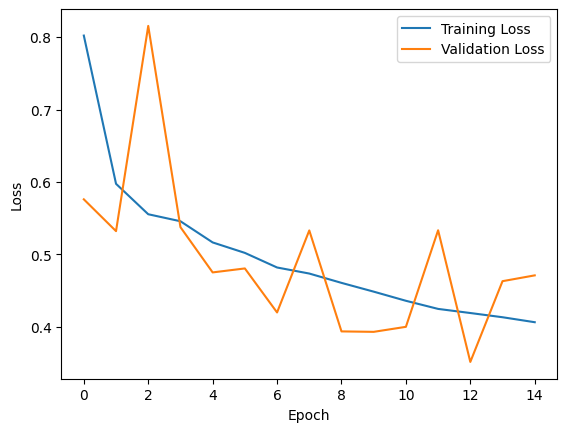

In [10]:
# Plot validation loss versus training loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Prediction

In [11]:

# Method to predict image labels of images uploaded from local machine
def predict_image(model, img_path):
    """
    Predict whether the given image is a Cat or Dog.

    Args:
        model: Trained Keras model
        img_path: Path to local image file (e.g., "my_cat.jpg")

    Returns:
        Predicted class index and confidence scores
    """
    # Load and preprocess image
    img = tf.keras.utils.load_img(img_path, target_size=(150, 150))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # add batch dimension
    img_array = img_array / 255.0             # normalize

    # Predict
    preds = model.predict(img_array)
    class_idx = np.argmax(preds[0])
    class_names = ["Cat", "Dog"]

    print(f"\n=============== Image Path :: {img_path}============= ")
    print(f"Prediction: {class_names[class_idx]} "
          f"(confidence: {preds[0][class_idx]:.2f})")
    plt.figure(figsize=(1,1))
    plt.imshow(img)
    plt.show()
    return class_names[class_idx], preds[0]

Saving breed_abyssinian_cat.jpg to breed_abyssinian_cat (1).jpg
Saving DC.jpg to DC (1).jpg
Saving download.jpg to download (1).jpg
Uploaded file: breed_abyssinian_cat (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

=============== Image Path :: breed_abyssinian_cat (1).jpg============= 
Prediction: Cat (confidence: 0.85)


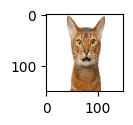

Uploaded file: DC (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

=============== Image Path :: DC (1).jpg============= 
Prediction: Dog (confidence: 1.00)


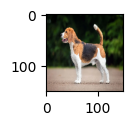

Uploaded file: download (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

=============== Image Path :: download (1).jpg============= 
Prediction: Cat (confidence: 0.76)


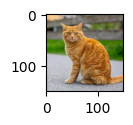

In [13]:
# Test the prediction with 5 images uploaded from local drive
from google.colab import files

# Step 1: Upload a file
uploaded = files.upload()

# Step 2: Get the filename
for filename in uploaded.keys():
    print("Uploaded file:", filename)

    # Step 3: Call predict_image on the uploaded file
    predict_image(model, filename)